# Telco Customer Churn Analysis & Retention Strategy
This notebook performs a comprehensive analysis of customer behavior to identify churn drivers and provide strategic recommendations for improving retention.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.dropna(inplace=True)


replace_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for i in replace_cols:
    df[i] = df[i].replace({'No internet service': 'No'})

display(df.head())
print(f'Dataset Shape: {df.shape}')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Dataset Shape: (7032, 21)


## 1. Churn Rates & Retention Trends
We will calculate the baseline churn rate and visualize how tenure affects retention.

Overall Churn Rate: 26.58%


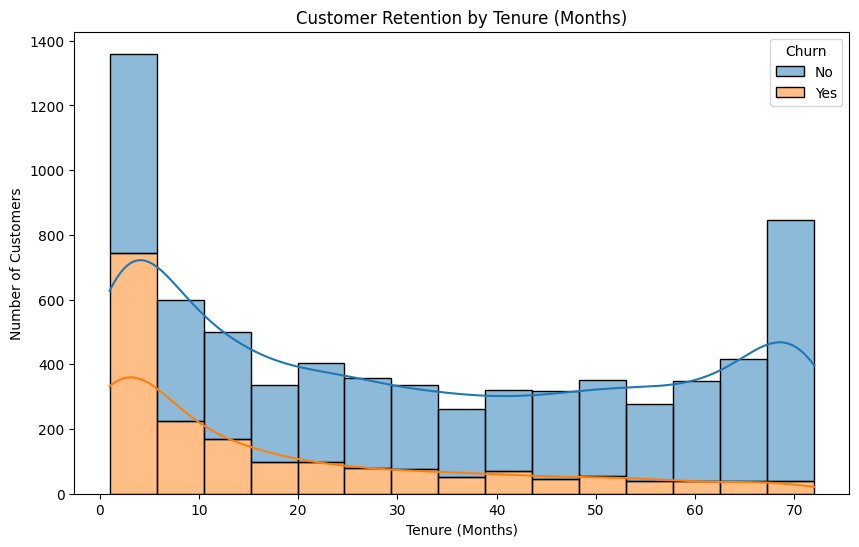

In [2]:
churn_rate = df['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f'Overall Churn Rate: {churn_rate:.2f}%')

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', kde=True)
plt.title('Customer Retention by Tenure (Months)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

## 2. Customer Cohort Analysis
Analyzing cohorts based on contract types and internet service plans to see where the highest risk lies.

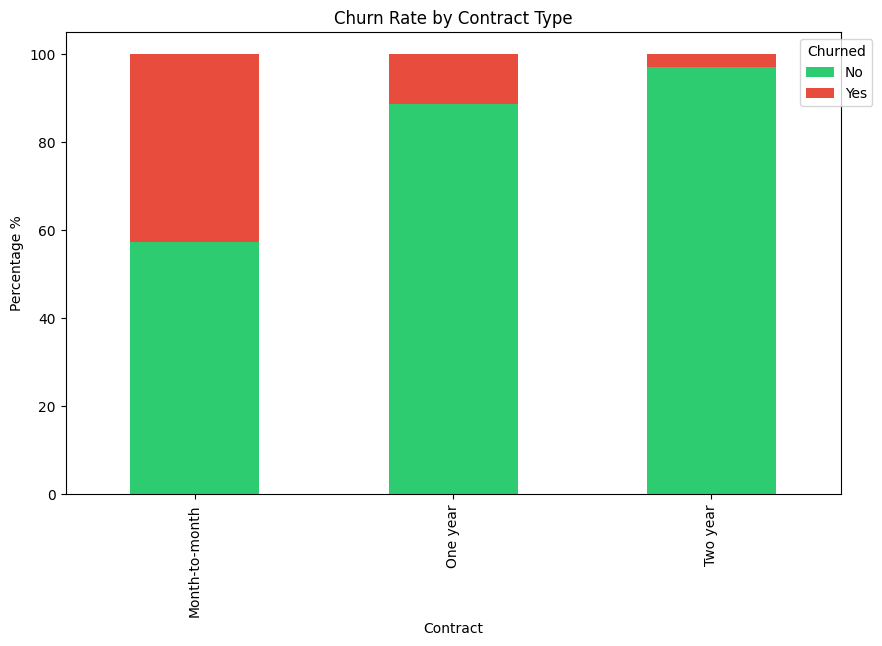

In [3]:
cohort_contract = df.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
cohort_contract_pct = cohort_contract.div(cohort_contract.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
cohort_contract_pct.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=plt.gca())
plt.title('Churn Rate by Contract Type')
plt.ylabel('Percentage %')
plt.legend(title='Churned', bbox_to_anchor=(1.05, 1))
plt.show()

## 3. Key Retention Drivers
Identifying which features (e.g., Tech Support, Fiber Optic) correlate most strongly with churn.

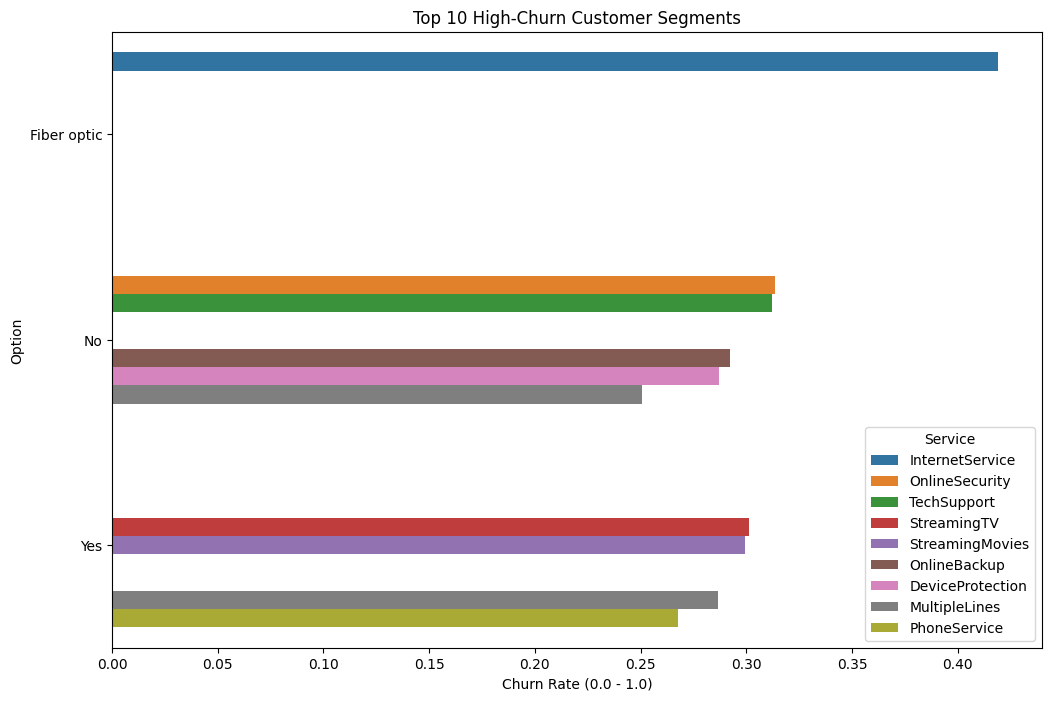

In [4]:
services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

churn_by_service = []
for service in services:
    temp = df.groupby([service, 'Churn']).size().unstack(fill_value=0)
    temp_pct = temp.div(temp.sum(axis=1), axis=0)['Yes']
    for idx, val in temp_pct.items():
        churn_by_service.append({'Service': service, 'Option': idx, 'Churn_Rate': val})

churn_drivers = pd.DataFrame(churn_by_service).sort_values(by='Churn_Rate', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=churn_drivers.head(10), x='Churn_Rate', y='Option', hue='Service')
plt.title('Top 10 High-Churn Customer Segments')
plt.xlabel('Churn Rate (0.0 - 1.0)')
plt.show()

## Final Executive Report & Dashboard

### Business Context
The current churn rate stands at **26.58%**. To improve retention, we have identified three primary areas of intervention: contract structures, high-risk service segments (Fiber Optic), and lack of security/support features.

### Strategic Recommendations
1.  **Contract Incentives:** Transition 'Month-to-Month' customers to long-term plans through targeted discounts, as they represent the highest churn risk.
2.  **Service Quality Check:** Investigate the 'Fiber Optic' segment, which shows unexpectedly high churn compared to DSL.
3.  **Support Bundling:** Bundle 'Tech Support' and 'Online Security' as standard features for high-risk cohorts to increase 'stickiness'.

/tmp/ipykernel_1766/1767788284.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cohort_contract_pct.index, y='Yes', data=cohort_contract_pct.reset_index(), ax=axes[0,0], palette='Reds_r')
/tmp/ipykernel_1766/1767788284.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1,1], palette='Set2')


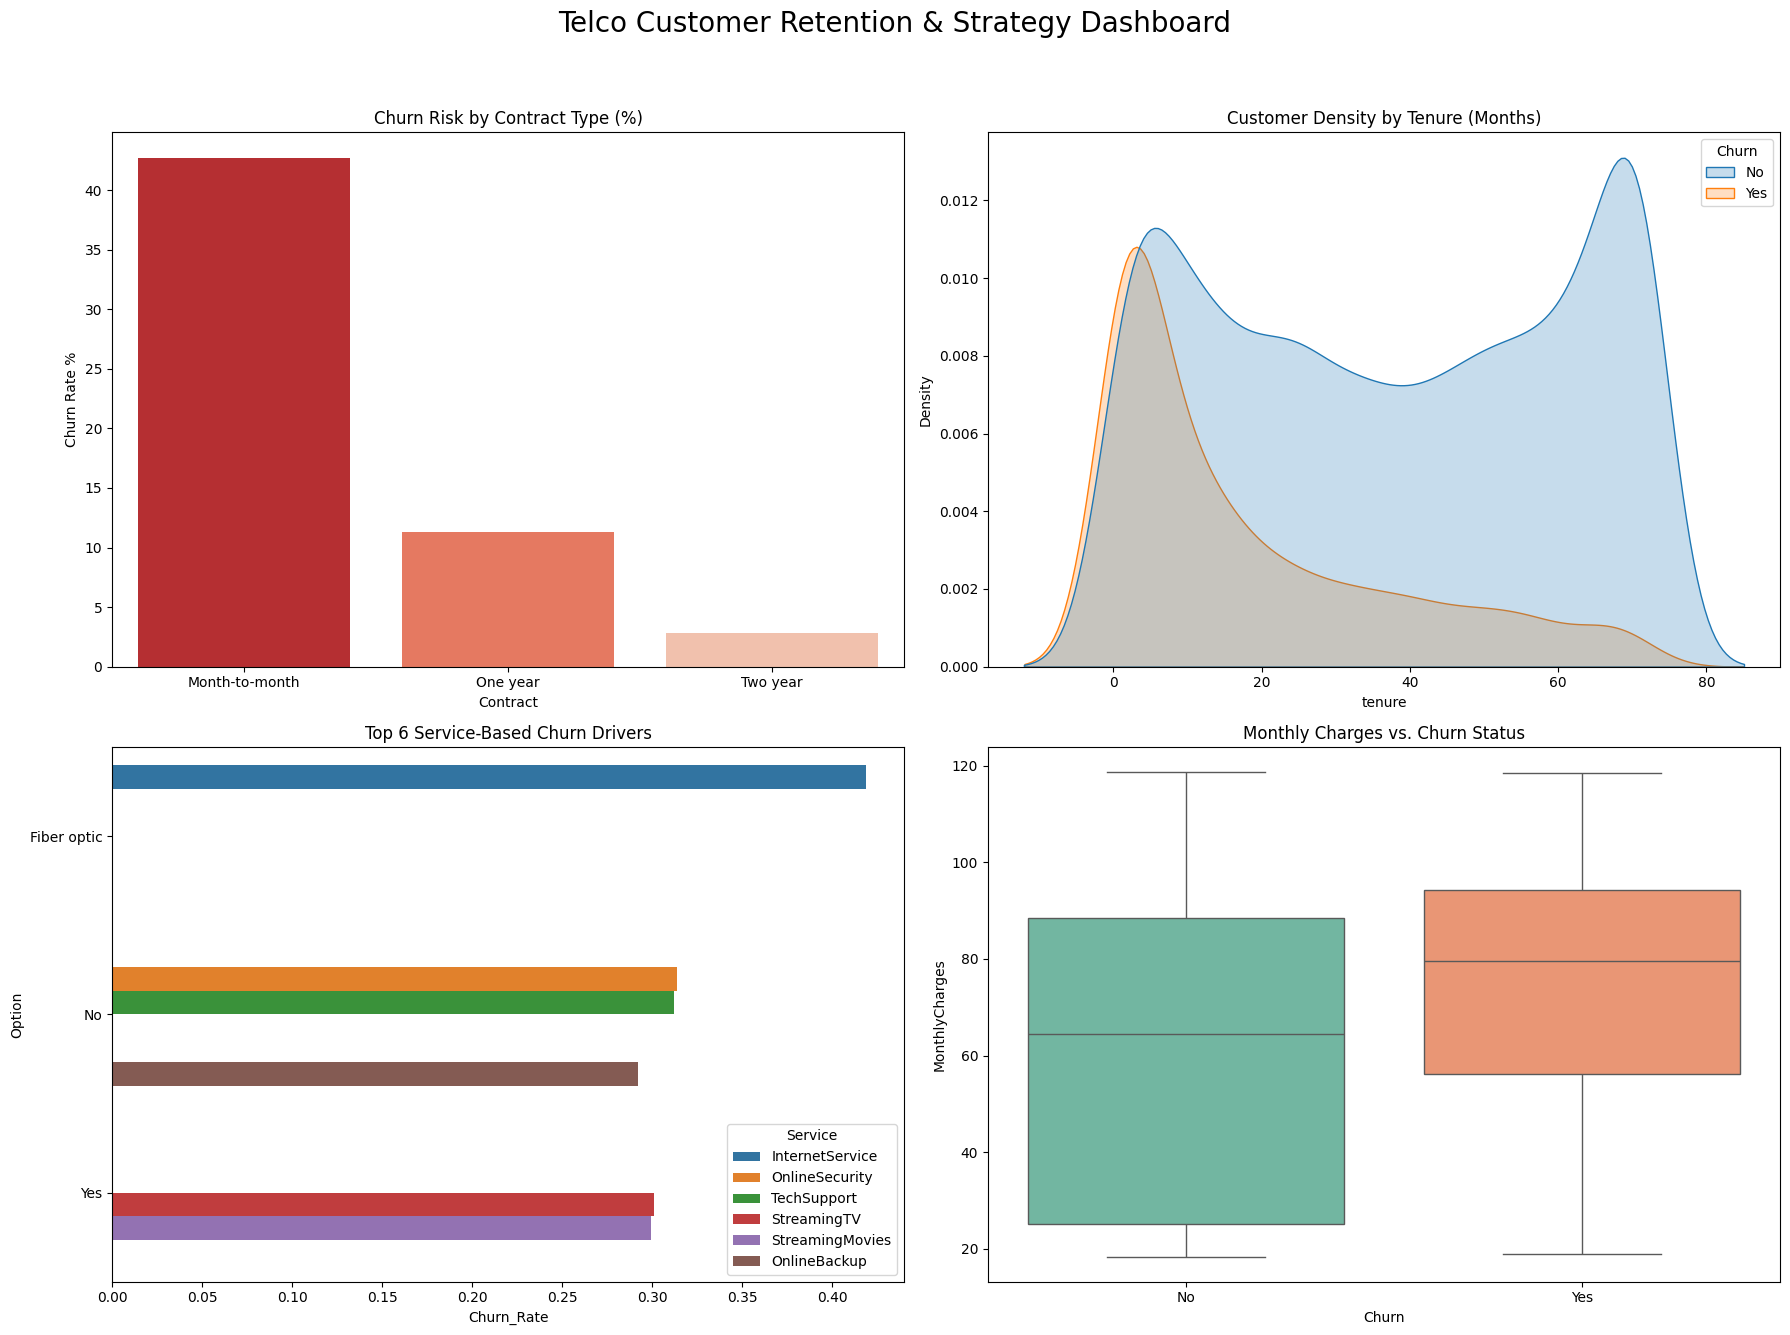

In [8]:

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Telco Customer Retention & Strategy Dashboard', fontsize=20)


sns.barplot(x=cohort_contract_pct.index, y='Yes', data=cohort_contract_pct.reset_index(), ax=axes[0,0], palette='Reds_r')
axes[0,0].set_title('Churn Risk by Contract Type (%)')
axes[0,0].set_ylabel('Churn Rate %')


sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, ax=axes[0,1])
axes[0,1].set_title('Customer Density by Tenure (Months)')


sns.barplot(data=churn_drivers.head(6), x='Churn_Rate', y='Option', hue='Service', ax=axes[1,0])
axes[1,0].set_title('Top 6 Service-Based Churn Drivers')


sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Monthly Charges vs. Churn Status')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [9]:
!pip install mpld3
import mpld3
from google.colab import files


html_content = mpld3.fig_to_html(fig)
with open('churn_dashboard.html', 'w') as f:
    f.write(html_content)


df.to_csv('cleaned_customer_data.csv', index=False)


print('Downloading files...')
files.download('churn_dashboard.html')
files.download('cleaned_customer_data.csv')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 6.9 MB/s eta 0:00:00


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>